# Model vs. Market — Section 7.5

Compares full-model predictions (xgb_with_elo) and Elo-only against pre-tipoff Kalshi and Polymarket
implied probabilities on the 2025 holdout.

**Outputs:**

| File | Purpose |
|---|---|
| `market_model_performance_summary.csv` | Headline log-loss / Brier / accuracy across sources |
| `market_logloss_by_disagreement_band.png` | Log-loss by disagreement band |
| `market_model_vs_market_probability_scatter.png` | Model vs market scatter |
| `market_directional_disagreement_table.csv` | Directional agreement counts |
| `market_coverage_summary_table.csv` | Game coverage by source |
| `market_polymarket_disagreement_band_table.csv` | Polymarket bands |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import log_loss, brier_score_loss

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from outputs import save_fig, save_table
from walkforward import fit_holdout_models
from markets import load_kalshi_pretipoff_probs, load_polymarket_pretipoff_probs

In [2]:
# Build holdout predictions for full model and Elo only
holdout_df, _ = fit_holdout_models(
    {'xgb_with_elo': {'type': 'xgb', 'use_bm': True}, 'elo': {'type': 'elo'}},
    holdout_year=2025,
)
model_preds = (
    holdout_df[holdout_df['model'] == 'xgb_with_elo'][['game_id', 'home_win', 'pred_prob']]
    .rename(columns={'pred_prob': 'model_prob'})
)
elo_preds = (
    holdout_df[holdout_df['model'] == 'elo'][['game_id', 'pred_prob']]
    .rename(columns={'pred_prob': 'elo_prob'})
)
kalshi = load_kalshi_pretipoff_probs()
poly   = load_polymarket_pretipoff_probs()

comp = (
    model_preds.merge(elo_preds, on='game_id')
      .merge(kalshi, on='game_id', how='left')
      .merge(poly,   on='game_id', how='left')
)
print(f'Total holdout games: {len(comp)}')
print(f'  with Kalshi:     {comp["kalshi_prob"].notna().sum()}')
print(f'  with Polymarket: {comp["poly_prob"].notna().sum()}')
print(f'  with both:       {(comp["kalshi_prob"].notna() & comp["poly_prob"].notna()).sum()}')

  xgb_with_elo             best_round=88
Total holdout games: 366
  with Kalshi:     349
  with Polymarket: 277
  with both:       263


---
## §7.5.1 — Headline summary table
**Table:** `market_model_performance_summary`.

In [3]:
def eval_metrics(y, p, label):
    mask = p.notna()
    yv, pv = y[mask].values, np.clip(p[mask].values, 0.01, 0.99)
    return {
        'source':   label,
        'n':        int(mask.sum()),
        'log_loss': float(log_loss(yv, pv)),
        'brier':    float(brier_score_loss(yv, pv)),
        'accuracy': float(((pv > 0.5) == yv).mean()),
    }

def summary_block(df, label):
    return pd.DataFrame([
        eval_metrics(df['home_win'], df['model_prob'],  'XGB + Elo (model)'),
        eval_metrics(df['home_win'], df['elo_prob'],    'Elo only'),
        eval_metrics(df['home_win'], df['kalshi_prob'], 'Kalshi pre-tipoff'),
        eval_metrics(df['home_win'], df['poly_prob'],   'Polymarket pre-tipoff'),
    ]).assign(scope=label)

common = comp[comp['kalshi_prob'].notna() & comp['poly_prob'].notna()]
summary = pd.concat([
    summary_block(comp,   'all available'),
    summary_block(common, f'common (n={len(common)})'),
], ignore_index=True)
save_table(summary, 'market_model_performance_summary')
summary

  saved: outputs\market_model_performance_summary.csv


,source,n,log_loss,brier,accuracy,scope
0,XGB + Elo (model),366,0.615922,0.212256,0.680328,all available
1,Elo only,366,0.618830,0.214462,0.672131,all available
2,Kalshi pre-tipoff,349,0.611546,0.212756,0.630372,all available
3,Polymarket pre-tipoff,277,0.673502,0.237251,0.624549,all available
4,XGB + Elo (model),263,0.625329,0.215543,0.688213,common (n=263)
5,Elo only,263,0.629123,0.218882,0.673004,common (n=263)
6,Kalshi pre-tipoff,263,0.617375,0.215114,0.631179,common (n=263)
7,Polymarket pre-tipoff,263,0.673826,0.237112,0.623574,common (n=263)


---
## §7.5.2 — Disagreement band log-loss
**Figure:** `market_logloss_by_disagreement_band`.

  saved: outputs\market_kalshi_disagreement_band_table.csv
  saved: outputs\market_polymarket_disagreement_band_table.csv
  saved: outputs\market_logloss_by_disagreement_band.png


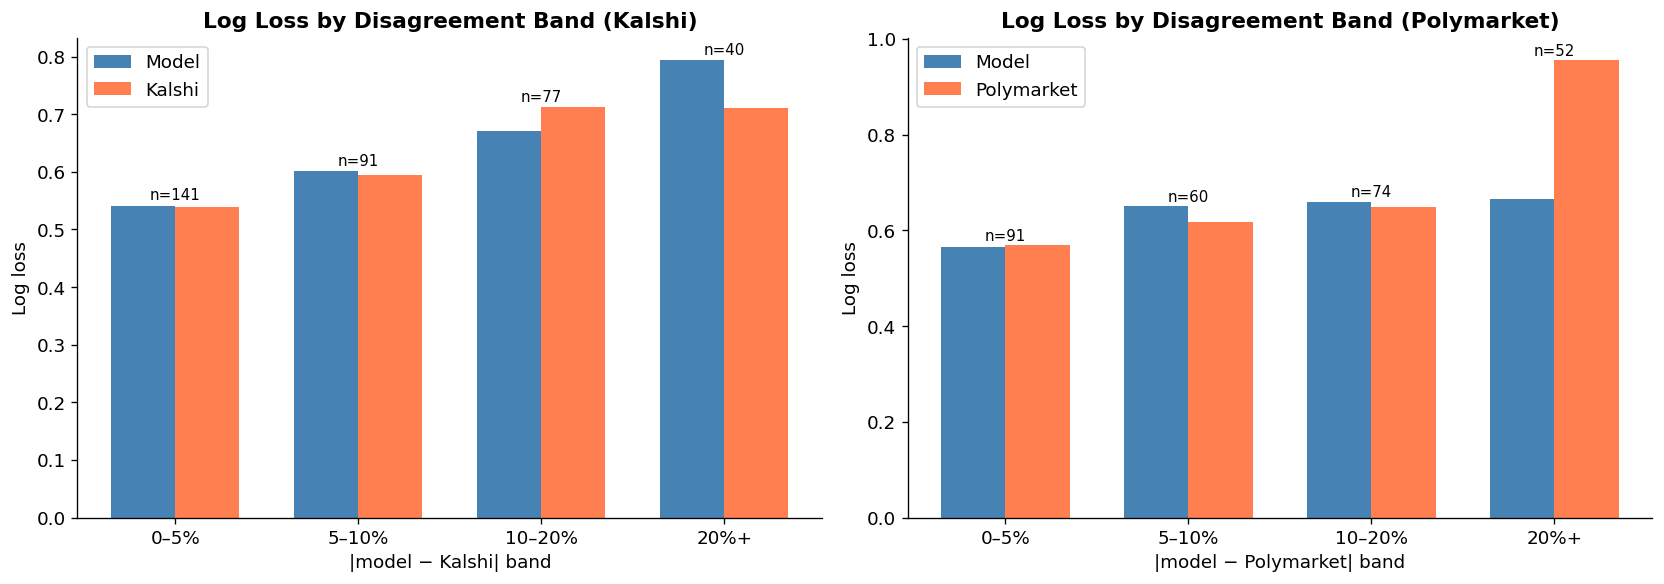

In [4]:
BAND_BINS  = [0, 0.05, 0.10, 0.20, 1.0]
BAND_LABEL = ['0–5%', '5–10%', '10–20%', '20%+']

def disagreement_table(df, model_col, market_col, market_name, y_col='home_win'):
    d = df.dropna(subset=[market_col]).copy()
    d['diff'] = (d[model_col] - d[market_col]).abs()
    d['band'] = pd.cut(d['diff'], bins=BAND_BINS, labels=BAND_LABEL, right=True)
    rows = []
    for band in BAND_LABEL:
        sub = d[d['band'] == band]
        if len(sub) == 0:
            continue
        y = sub[y_col].values
        mp = np.clip(sub[model_col].values, 0.01, 0.99)
        mkt = np.clip(sub[market_col].values, 0.01, 0.99)
        rows.append({
            'band': band, 'n': len(sub),
            'model_ll':  log_loss(y, mp),
            f'{market_name}_ll': log_loss(y, mkt),
            'model_acc': ((mp > 0.5) == y).mean(),
            f'{market_name}_acc': ((mkt > 0.5) == y).mean(),
            'mean_diff': sub['diff'].mean(),
        })
    return pd.DataFrame(rows)

bands_k = disagreement_table(comp, 'model_prob', 'kalshi_prob', 'kalshi')
bands_p = disagreement_table(comp, 'model_prob', 'poly_prob',   'poly')
save_table(bands_k, 'market_kalshi_disagreement_band_table')
save_table(bands_p, 'market_polymarket_disagreement_band_table')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (bands, market_name, market_label) in zip(
    axes, [(bands_k, 'kalshi', 'Kalshi'), (bands_p, 'poly', 'Polymarket')],
):
    if len(bands) == 0:
        continue
    x = range(len(bands)); w = 0.35
    ax.bar([i - w/2 for i in x], bands['model_ll'],            w, label='Model',     color='steelblue')
    ax.bar([i + w/2 for i in x], bands[f'{market_name}_ll'],   w, label=market_label, color='coral')
    ax.set_xticks(list(x)); ax.set_xticklabels(bands['band'])
    for i, row in bands.iterrows():
        ax.text(i, max(row['model_ll'], row[f'{market_name}_ll']) + 0.01,
                f'n={int(row["n"])}', ha='center', fontsize=9)
    ax.set_ylabel('Log loss')
    ax.set_xlabel(f'|model − {market_label}| band')
    ax.set_title(f'Log Loss by Disagreement Band ({market_label})', fontweight='bold')
    ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'market_logloss_by_disagreement_band')
plt.show()

---
## §7.5 Appendix

  saved: outputs\market_model_vs_market_probability_scatter.png


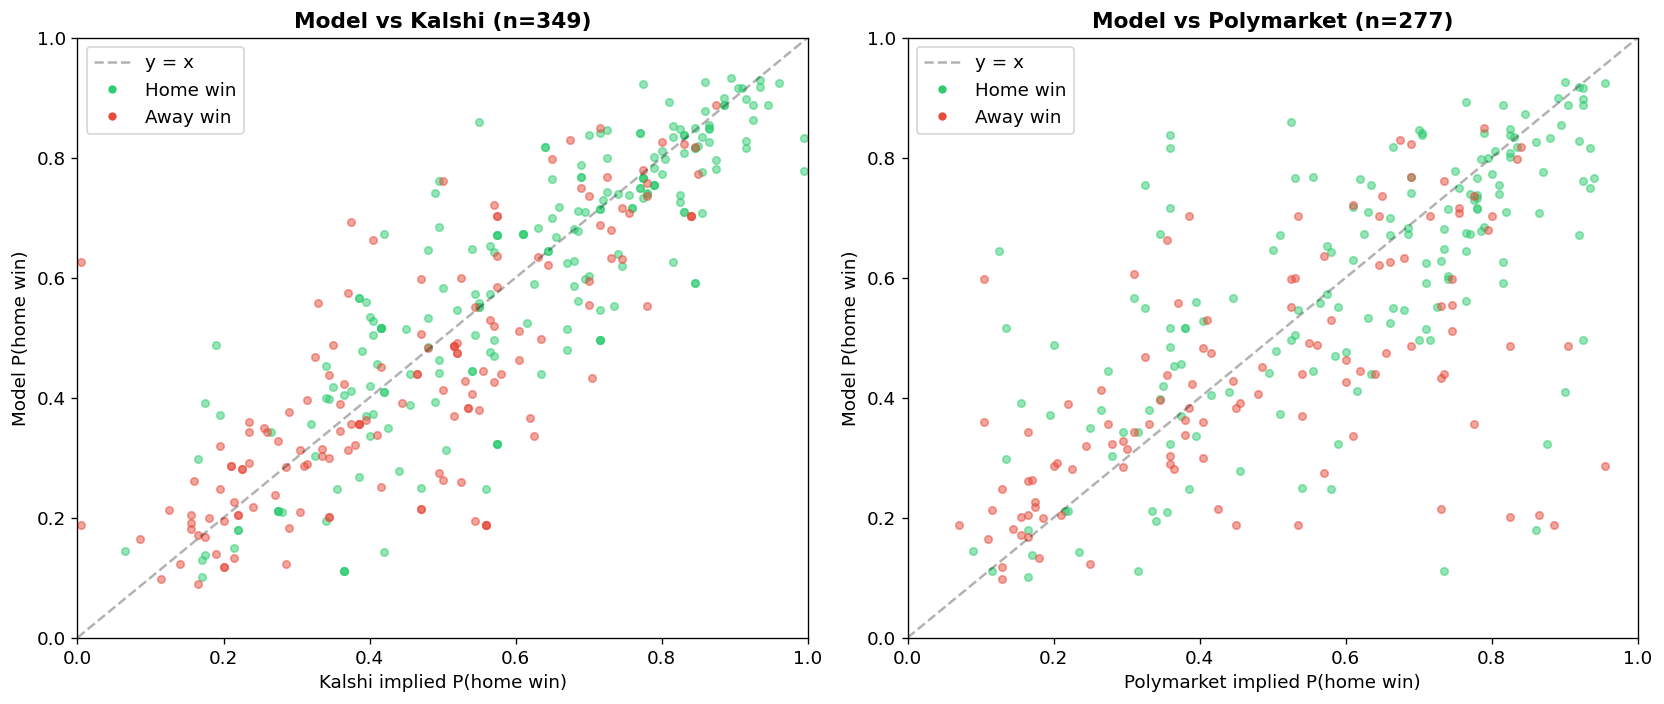

In [5]:
# Scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (mcol, mname) in zip(axes, [('kalshi_prob', 'Kalshi'), ('poly_prob', 'Polymarket')]):
    sub = comp.dropna(subset=[mcol])
    home = sub[sub['home_win'] == 1]; away = sub[sub['home_win'] == 0]
    ax.scatter(home[mcol], home['model_prob'], c='#2ecc71', alpha=0.5, s=20)
    ax.scatter(away[mcol], away['model_prob'], c='#e74c3c', alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel(f'{mname} implied P(home win)')
    ax.set_ylabel('Model P(home win)')
    ax.set_title(f'Model vs {mname} (n={len(sub)})', fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(handles=[
        Line2D([], [], color='k', ls='--', alpha=0.3, label='y = x'),
        Line2D([], [], marker='o', color='w', markerfacecolor='#2ecc71', markersize=6, label='Home win'),
        Line2D([], [], marker='o', color='w', markerfacecolor='#e74c3c', markersize=6, label='Away win'),
    ], loc='upper left')
plt.tight_layout()
save_fig(fig, 'market_model_vs_market_probability_scatter')
plt.show()

In [6]:
# Directional disagreement and coverage
def directional_table(df, market_col, market_name):
    d = df.dropna(subset=[market_col]).copy()
    d['model_pick_home']  = d['model_prob']  > 0.5
    d['market_pick_home'] = d[market_col]    > 0.5
    d['actual_home_win']  = d['home_win']    == 1
    d['disagree']         = d['model_pick_home'] != d['market_pick_home']
    n_agree    = int((~d['disagree']).sum())
    n_disagree = int(d['disagree'].sum())
    if n_disagree:
        m_right = float((d.loc[d['disagree'], 'model_pick_home']  == d.loc[d['disagree'], 'actual_home_win']).mean())
        k_right = float((d.loc[d['disagree'], 'market_pick_home'] == d.loc[d['disagree'], 'actual_home_win']).mean())
    else:
        m_right, k_right = float('nan'), float('nan')
    if n_agree:
        joint_acc = float((d.loc[~d['disagree'], 'model_pick_home'] == d.loc[~d['disagree'], 'actual_home_win']).mean())
    else:
        joint_acc = float('nan')
    return {
        'market': market_name, 'n': len(d),
        'agree': n_agree, 'disagree': n_disagree,
        'pct_disagree': n_disagree / len(d),
        'model_right_when_disagree':  m_right,
        'market_right_when_disagree': k_right,
        'joint_accuracy_when_agree':  joint_acc,
    }

directional = pd.DataFrame([
    directional_table(comp, 'kalshi_prob', 'Kalshi'),
    directional_table(comp, 'poly_prob',   'Polymarket'),
])
save_table(directional, 'market_directional_disagreement_table')

coverage = pd.DataFrame([{
    'total_holdout_games': len(comp),
    'with_kalshi':     int(comp['kalshi_prob'].notna().sum()),
    'with_polymarket': int(comp['poly_prob'].notna().sum()),
    'with_both':       int((comp['kalshi_prob'].notna() & comp['poly_prob'].notna()).sum()),
    'kalshi_only':     int((comp['kalshi_prob'].notna() & comp['poly_prob'].isna()).sum()),
    'poly_only':       int((comp['kalshi_prob'].isna() & comp['poly_prob'].notna()).sum()),
}])
save_table(coverage, 'market_coverage_summary_table')
directional

  saved: outputs\market_directional_disagreement_table.csv
  saved: outputs\market_coverage_summary_table.csv


,market,n,agree,disagree,pct_disagree,model_right_when_disagree,market_right_when_disagree,joint_accuracy_when_agree
0,Kalshi,349,283,66,0.189112,0.651515,0.348485,0.696113
1,Polymarket,277,214,63,0.227437,0.619048,0.380952,0.696262
